In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,roc_auc_score, roc_curve, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="husl")
plt.rcParams["figure.dpi"] = 120
print("Libraries loaded successfully")

Libraries loaded successfully


## 1. Load & Inspect Data

In [4]:
df = pd.read_csv("customer_churn_prediction.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Data Cleaning

In [8]:
# Fix TotalCharges — stored as string with whitespace
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Rows where TotalCharges is NaN (tenure == 0, new customers)
print(f"NaN in TotalCharges: {df["TotalCharges"].isna().sum()}")
df["TotalCharges"].fillna(0, inplace=True)

# Encode target
df["Churn"] = (df["Churn"] == "Yes").astype(int)

# Drop customerID (not predictive)
df.drop(columns=["customerID"], inplace=True)

print(f"Churn rate: {df["Churn"].mean():.2%}")

NaN in TotalCharges: 11
Churn rate: 26.54%


## 3. Exploratory Data Analysis

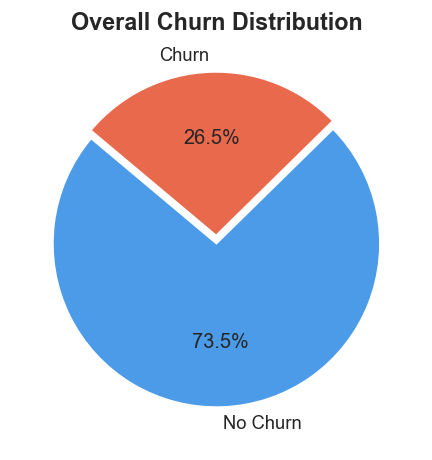

In [9]:
fig, ax = plt.subplots(figsize=(5,4))
churn_counts = df["Churn"].value_counts()
ax.pie(churn_counts, labels=["No Churn","Churn"], autopct="%1.1f%%",
       colors=["#4C9BE8","#E8694C"], startangle=140, explode=[0,0.05])
ax.set_title("Overall Churn Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("plot_churn_dist.png")
plt.show()

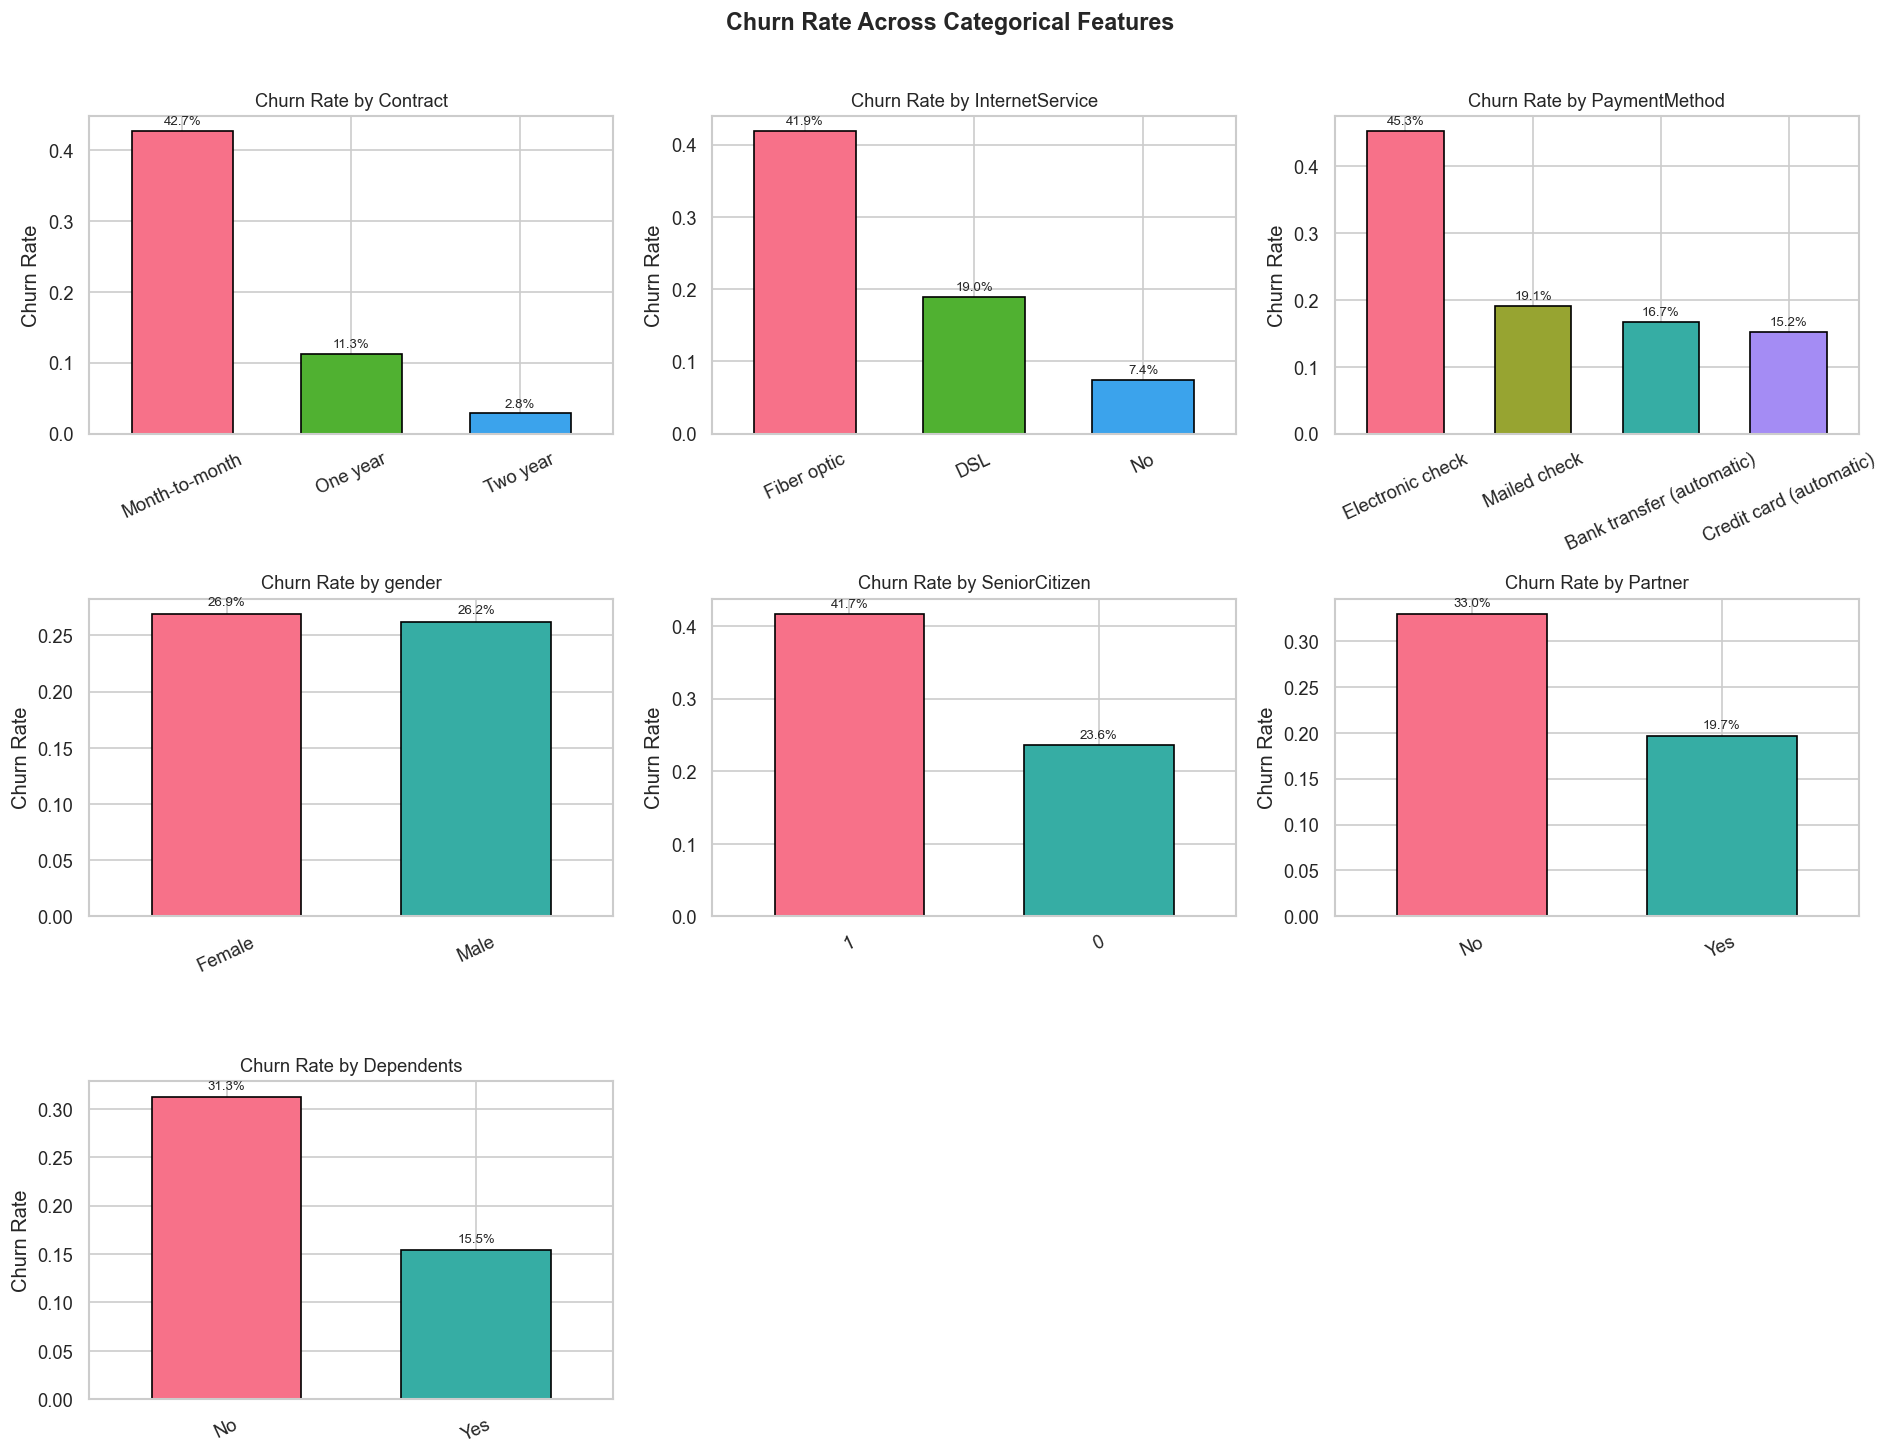

In [10]:
# Churn by contract type, internet service, payment method
cat_cols = ["Contract","InternetService","PaymentMethod","gender","SeniorCitizen","Partner","Dependents"]
fig, axes = plt.subplots(3, 3, figsize=(16,12))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    ct = df.groupby(col)["Churn"].mean().sort_values(ascending=False)
    ct.plot(kind="bar", ax=axes[i], color=sns.color_palette("husl", len(ct)),
            edgecolor="black", width=0.6)
    axes[i].set_title(f"Churn Rate by {col}", fontsize=11)
    axes[i].set_ylabel("Churn Rate")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=25)
    for bar in axes[i].patches:
        axes[i].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                     f"{bar.get_height():.1%}", ha="center", va="bottom", fontsize=8)
for j in range(i+1, len(axes)): axes[j].set_visible(False)
plt.suptitle("Churn Rate Across Categorical Features", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("plot_categorical.png")
plt.show()

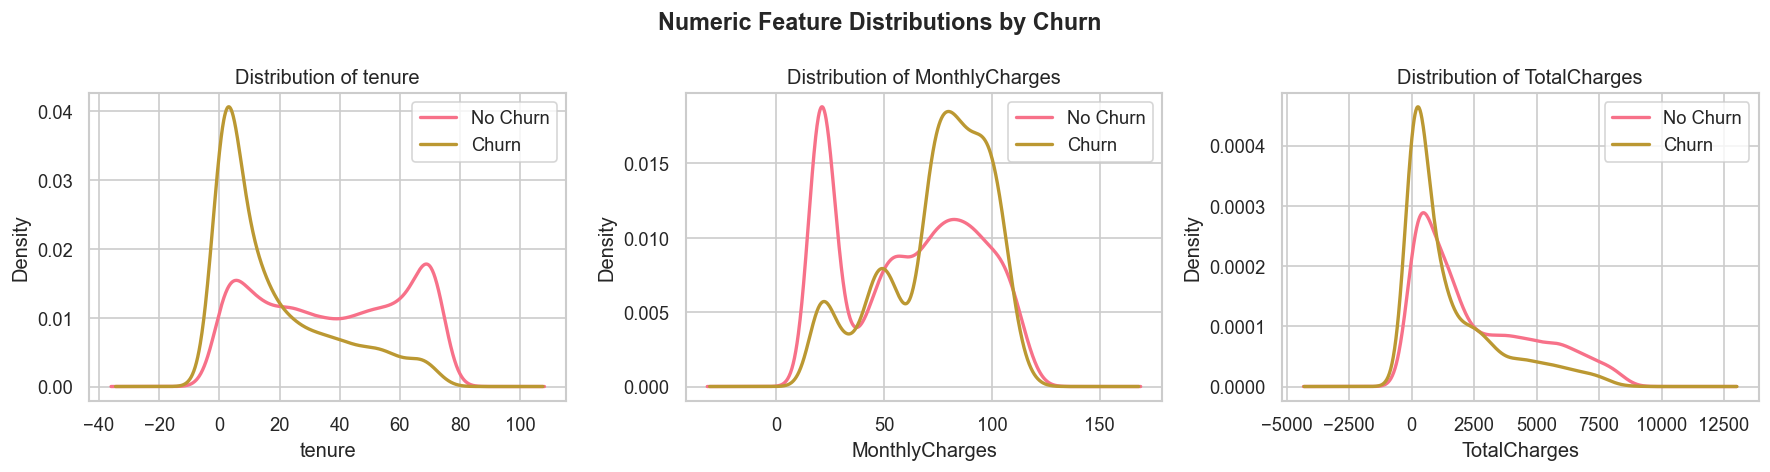

In [11]:
# Numeric distributions by churn
num_cols = ["tenure","MonthlyCharges","TotalCharges"]
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, col in zip(axes, num_cols):
    for label, grp in df.groupby("Churn"):
        grp[col].plot.kde(ax=ax, label=["No Churn","Churn"][label], linewidth=2)
    ax.set_title(f"Distribution of {col}", fontsize=12)
    ax.set_xlabel(col)
    ax.legend()
plt.suptitle("Numeric Feature Distributions by Churn", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("plot_numeric_dist.png")
plt.show()

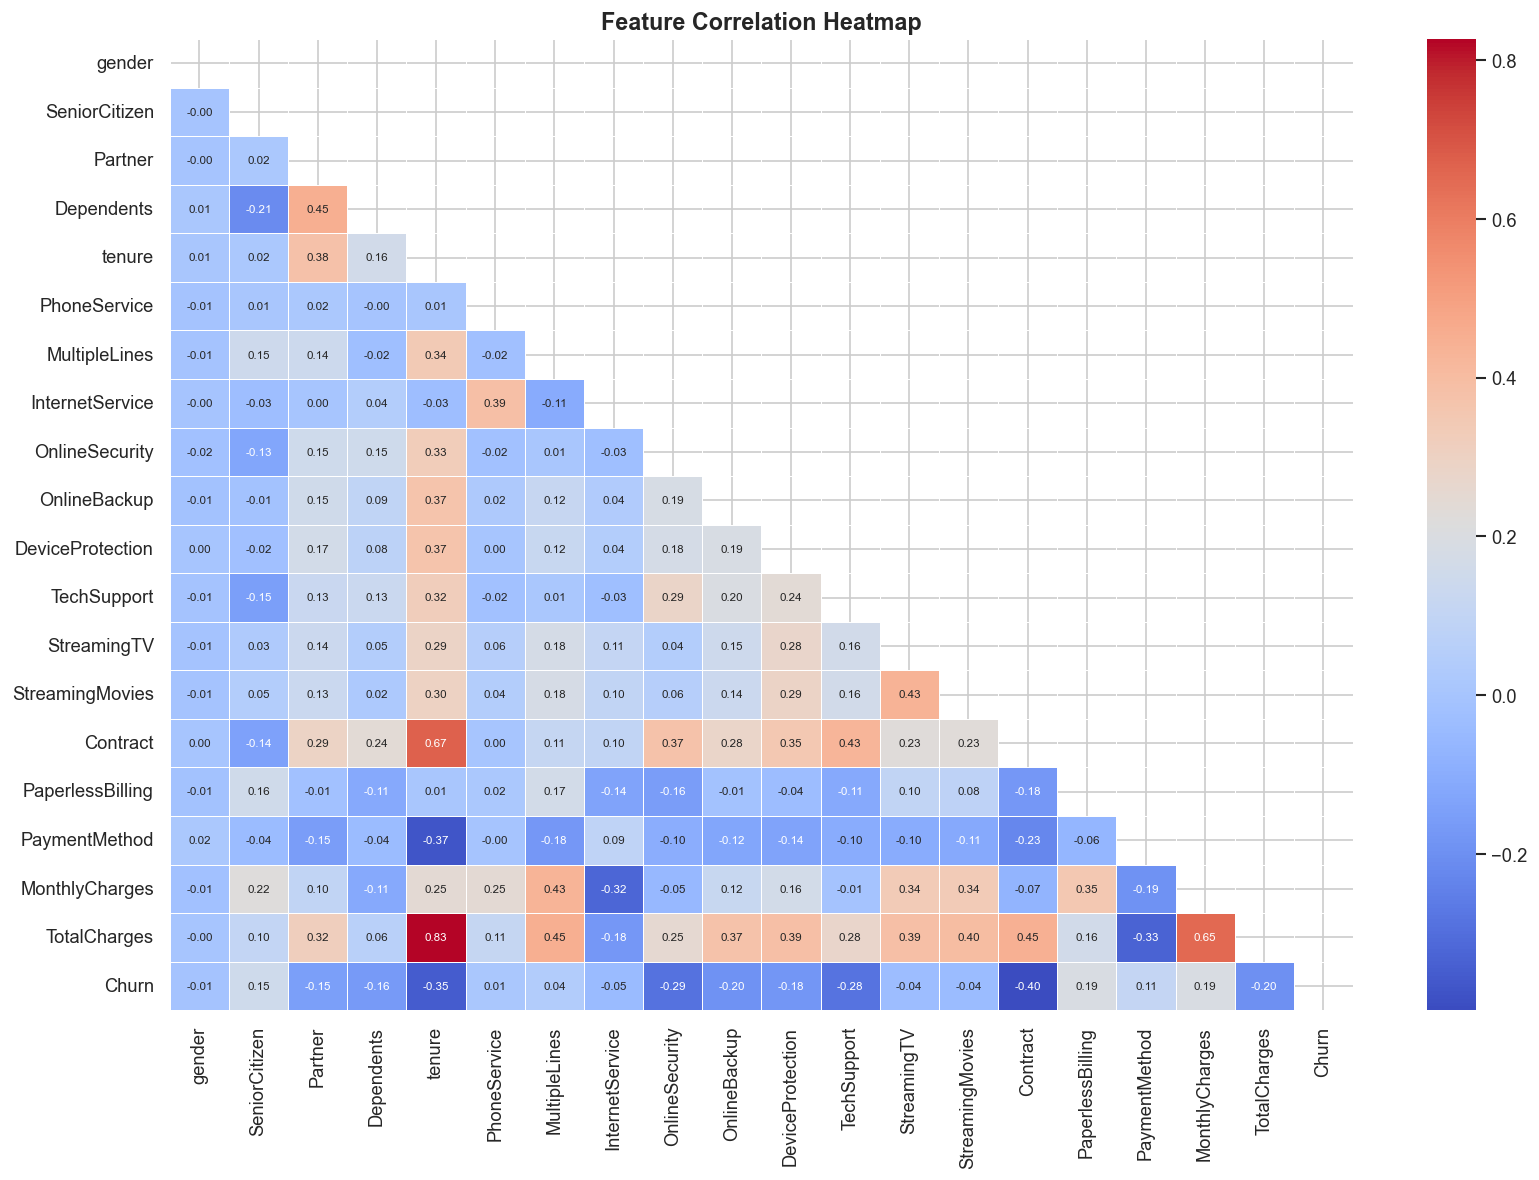

In [12]:
# Correlation heatmap (numeric + encoded binary)
df_corr = df.copy()
for c in df_corr.select_dtypes("object").columns:
    df_corr[c] = LabelEncoder().fit_transform(df_corr[c])
corr = df_corr.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(14,10))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, ax=ax, annot_kws={"size":7})
ax.set_title("Feature Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("plot_heatmap.png")
plt.show()

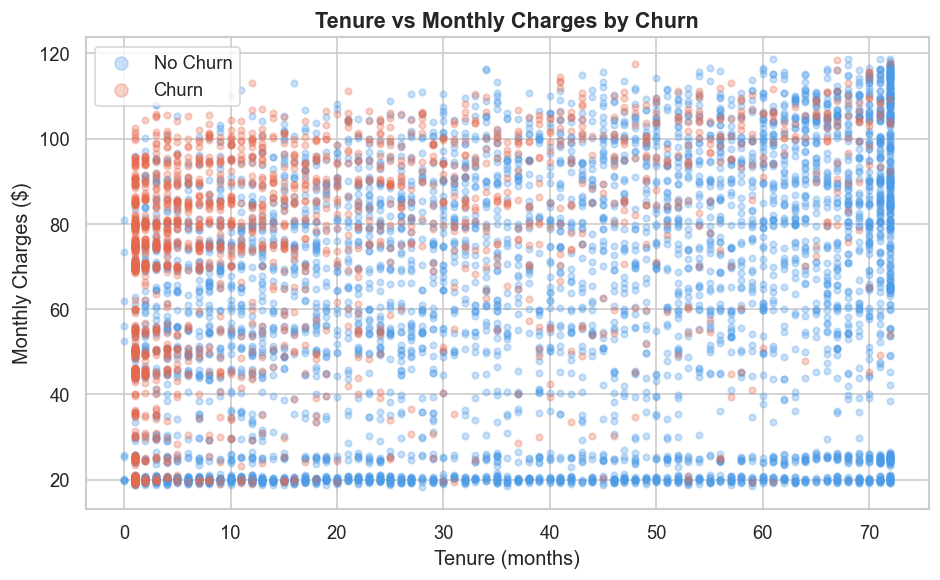

In [13]:
# Tenure vs MonthlyCharges scatter coloured by churn
fig, ax = plt.subplots(figsize=(8,5))
colors = {0:"#4C9BE8", 1:"#E8694C"}
for label, grp in df.groupby("Churn"):
    ax.scatter(grp["tenure"], grp["MonthlyCharges"], alpha=0.3, s=15,
               c=colors[label], label=["No Churn","Churn"][label])
ax.set_xlabel("Tenure (months)"); ax.set_ylabel("Monthly Charges ($)")
ax.set_title("Tenure vs Monthly Charges by Churn", fontsize=13, fontweight="bold")
ax.legend(markerscale=2)
plt.tight_layout()
plt.savefig("plot_scatter.png")
plt.show()

## 4. Feature Engineering & Preprocessing

In [14]:
df_model = df.copy()

# Binary yes/no cols
binary_cols = [c for c in df_model.select_dtypes("object").columns
               if set(df_model[c].unique()) <= {"Yes","No"}]
for c in binary_cols:
    df_model[c] = (df_model[c] == "Yes").astype(int)

# One-hot encode remaining categoricals
df_model = pd.get_dummies(df_model, drop_first=True)

print(f"Features after encoding: {df_model.shape[1]-1}")
df_model.head(3)

Features after encoding: 30


,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,gender_Male,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,0,1,29.85,29.85,0,False,...,False,False,False,False,False,False,False,False,True,False
1,0,0,0,34,1,0,56.95,1889.50,0,True,...,False,False,False,False,False,True,False,False,False,True
2,0,0,0,2,1,1,53.85,108.15,1,True,...,False,False,False,False,False,False,False,False,False,True


## 5. Model Training & Evaluation

In [15]:
X = df_model.drop("Churn", axis=1)
y = df_model["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Train: 5634 | Test: 1409


In [16]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest":       RandomForestClassifier(n_estimators=50, random_state=42),  # 50 instead of 200
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=50, random_state=42),

}
results = {}
for name, model in models.items():
    Xtr, Xte = (X_train_s, X_test_s) if "Logistic" in name else (X_train, X_test)
    model.fit(Xtr, y_train)
    preds = model.predict(Xte)
    proba = model.predict_proba(Xte)[:,1]
    auc   = roc_auc_score(y_test, proba)
    results[name] = {"model":model, "preds":preds, "proba":proba, "auc":auc}
    print(f"\n=== {name} (AUC={auc:.4f}) ===")
    print(classification_report(y_test, preds, target_names=["No Churn","Churn"]))


=== Logistic Regression (AUC=0.8414) ===
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409


=== Random Forest (AUC=0.8218) ===
              precision    recall  f1-score   support

    No Churn       0.83      0.89      0.86      1035
       Churn       0.63      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409


=== Gradient Boosting (AUC=0.8447) ===
              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.86      1035
       Churn       0.64      0.49      0.56       374

    accuracy                           0.79      1409
   macro a

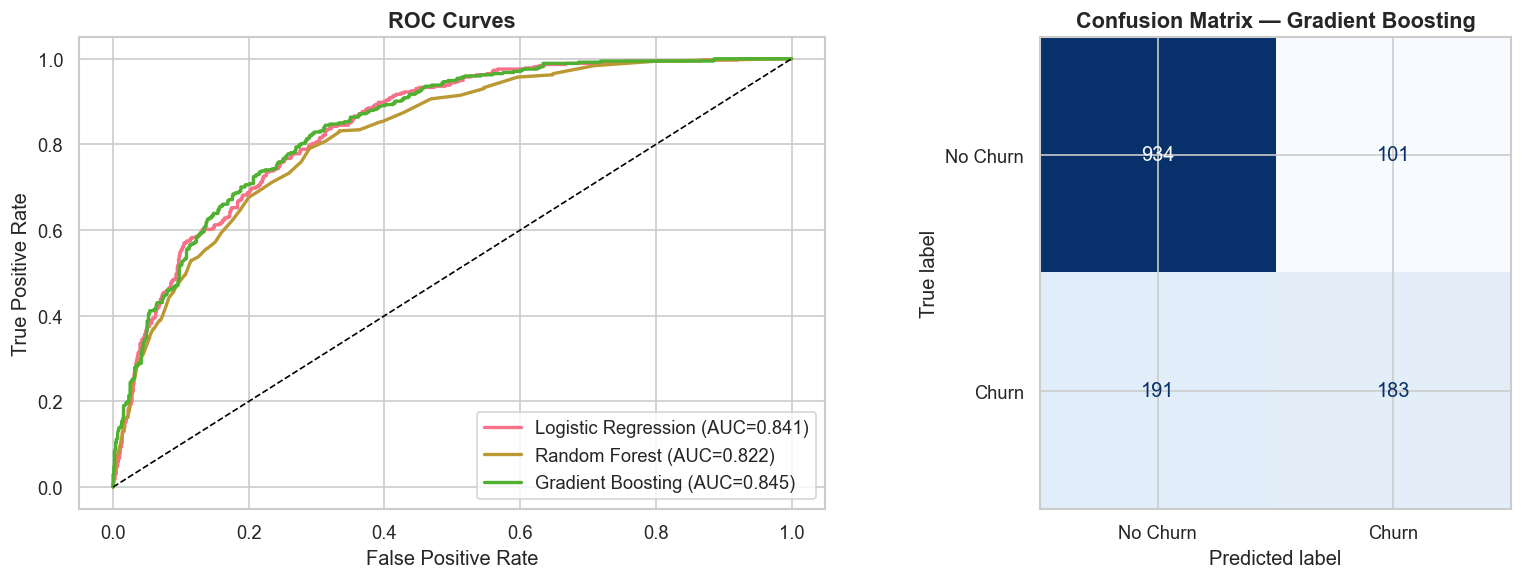

In [17]:
# ROC curves
fig, axes = plt.subplots(1, 2, figsize=(14,5))

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["proba"])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={res["auc"]:.3f})", linewidth=2)
axes[0].plot([0,1],[0,1],"k--", linewidth=1)
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves", fontsize=13, fontweight="bold")
axes[0].legend()

# Confusion matrix for best model
best_name = max(results, key=lambda k: results[k]["auc"])
best_preds = results[best_name]["preds"]
cm = confusion_matrix(y_test, best_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["No Churn","Churn"])
disp.plot(ax=axes[1], cmap="Blues", colorbar=False)
axes[1].set_title(f"Confusion Matrix — {best_name}", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("plot_roc_cm.png")
plt.show()

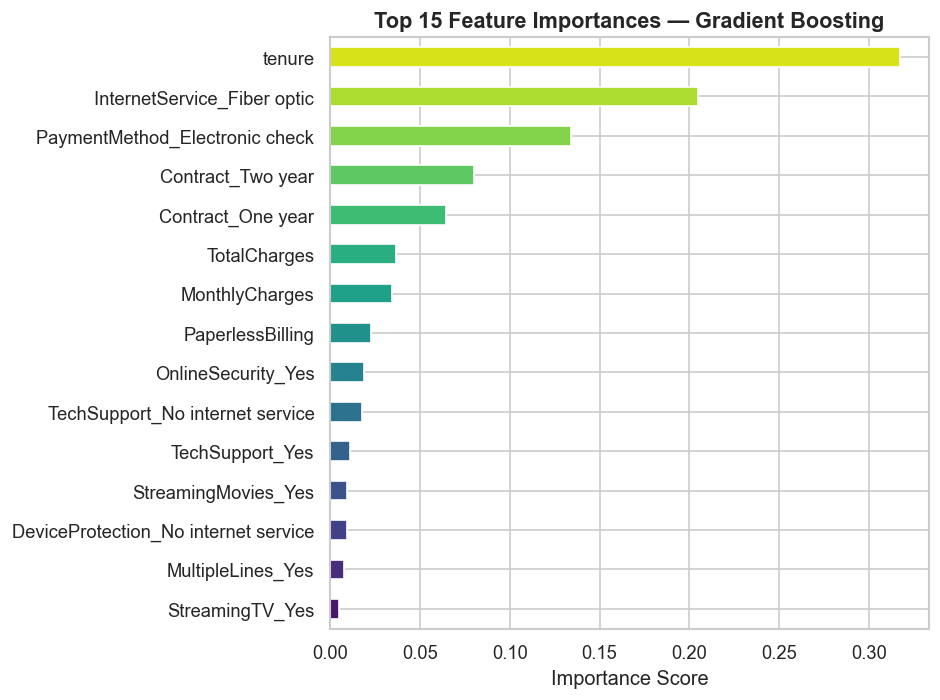

In [18]:
# Feature importances (best tree model)
best_tree = max({k:v for k,v in results.items() if k != "Logistic Regression"},
                key=lambda k: results[k]["auc"])
importances = pd.Series(results[best_tree]["model"].feature_importances_,
                         index=X.columns).nlargest(15)

fig, ax = plt.subplots(figsize=(8,6))
importances[::-1].plot.barh(ax=ax, color=sns.color_palette("viridis", len(importances)))
ax.set_title(f"Top 15 Feature Importances — {best_tree}", fontsize=13, fontweight="bold")
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.savefig("plot_feature_importance.png")
plt.show()

## 6. Summary

| Model | AUC |
|---|---|
| See results above |

**Key findings:**
- Customers on **Month-to-month** contracts churn at ~42% — far above annual/biennial plans.
- **Tenure** is the strongest predictor: new customers are most at risk.
- **High MonthlyCharges** combined with low tenure signals high churn probability.
- **Fiber optic** internet users churn more than DSL or no-internet users.
- **Electronic check** payers have the highest churn rate among payment methods.